# Sentinel-5P CH4 Data Fetcher

This notebook fetches methane (CH4) data from Sentinel-5P satellite over a specified region and date range.

**Configuration variables are in the next cell - change them as needed!**

## Authentication Setup

**First Time Setup**: When you run the authentication cell below, it will:
1. Try to initialize Earth Engine
2. If not authenticated, it will open a browser window for Google login
3. Follow the prompts to authorize Earth Engine access
4. Once done, the authentication will persist for future sessions

**Note**: The `earthengine-api` package is already installed in your environment.

In [15]:
# ============================================================================
# CONFIGURATION - Change these variables as needed
# ============================================================================

# Earth Engine Project ID (update with your project)
EE_PROJECT = "quick-composite-408320"

# Region of interest
COUNTRY_NAME = 'Sweden'  # Change to any country name (e.g., 'Italy', 'France', 'Germany')

# Date range (YYYY-MM-DD format)
START_DATE = '2024-01-01'
END_DATE = '2024-01-02'

# Band to analyze
BAND_NAME = 'CH4_column_volume_mixing_ratio_dry_air'

# Dataset
DATASET_ID = 'COPERNICUS/S5P/OFFL/L3_CH4'

print(f"Configuration:")
print(f"  Region: {COUNTRY_NAME}")
print(f"  Date range: {START_DATE} to {END_DATE}")
print(f"  Band: {BAND_NAME}")
print(f"  Dataset: {DATASET_ID}")

Configuration:
  Region: Sweden
  Date range: 2024-01-01 to 2024-01-02
  Band: CH4_column_volume_mixing_ratio_dry_air
  Dataset: COPERNICUS/S5P/OFFL/L3_CH4


In [12]:
import ee

# Run `earthengine authenticate` in terminal first if not already authenticated

try:
    ee.Initialize(project=EE_PROJECT)
    print(f"✓ Earth Engine initialized with project: {EE_PROJECT}")
except Exception as e:
    print("Authentication needed. Running ee.Authenticate()...")
    ee.Authenticate()
    ee.Initialize(project=EE_PROJECT)
    print(f"✓ Earth Engine initialized with project: {EE_PROJECT}")

✓ Earth Engine initialized with project: quick-composite-408320


In [13]:
# Load Sentinel-5P CH4 collection with date filter
collection = ee.ImageCollection(DATASET_ID) \
    .select(BAND_NAME) \
    .filterDate(START_DATE, END_DATE)

print(f"Loaded collection: {collection.size().getInfo()} images total")


Loaded collection: 4636 images total


## Save Data Locally

The next cell saves the fetched data to both CSV and JSON formats in the `data/` directory.

**CSV format**: Simple table with columns `date` and `mean_ch4` - easy to use in spreadsheets or pandas
**JSON format**: Includes metadata (country, date range, number of observations, etc.) along with the data

In [ ]:
# Save the raw results to CSV and JSON
import json
import os
from datetime import datetime

if results:
    # Create data directory if it doesn't exist
    data_dir = '../data'
    os.makedirs(data_dir, exist_ok=True)
    
    # Generate filename with timestamp
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    filename_base = f"ch4_{COUNTRY_NAME.lower().replace(' ', '_')}_{START_DATE}_to_{END_DATE}"
    
    # Save as CSV
    csv_path = os.path.join(data_dir, f"{filename_base}.csv")
    import pandas as pd
    results_df = pd.DataFrame(results)
    results_df.to_csv(csv_path, index=False)
    print(f"✓ Saved to CSV: {csv_path}")
    
    # Save as JSON
    json_path = os.path.join(data_dir, f"{filename_base}.json")
    with open(json_path, 'w') as f:
        json.dump({
            'metadata': {
                'country': COUNTRY_NAME,
                'start_date': START_DATE,
                'end_date': END_DATE,
                'band': BAND_NAME,
                'dataset': DATASET_ID,
                'total_images': total_size,
                'valid_images': valid_size,
                'observations': len(results),
                'fetched_at': timestamp
            },
            'data': results
        }, f, indent=2)
    print(f"✓ Saved to JSON: {json_path}")
    
    print(f"\n📊 Summary:")
    print(f"   Total observations: {len(results)}")
    print(f"   Date range: {results[0]['date']} to {results[-1]['date']}")
    print(f"   Files saved in: {os.path.abspath(data_dir)}")
else:
    print("⚠ No data to save. Run the previous cell first or adjust the date range.")

⚠ No data to save. Run the previous cell first or adjust the date range.


In [38]:
# Build DataFrame of valid daily means & summary stats
import pandas as pd

try:
    results  # ensure results exists from previous cell
except NameError:
    raise RuntimeError("Run the previous cell that builds 'results' first.")

# Some days may repeat (multiple orbits); aggregate by date average
import math
from statistics import mean

# Collect by date
by_date = {}
for r in results:
    d = r['date']
    v = r['mean_ch4']
    if v is None or (isinstance(v, float) and (math.isnan(v) or math.isinf(v))):
        continue
    by_date.setdefault(d, []).append(v)

rows = [(d, mean(vals)) for d, vals in by_date.items()]
if not rows:
    raise ValueError("No numeric rows to build DataFrame.")

import datetime as dt

df = pd.DataFrame(rows, columns=['date', 'mean_ch4'])
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print("DataFrame shape:", df.shape)
print("First 5 rows:\n", df.head())
print("\nSummary statistics:\n", df['mean_ch4'].describe())

ValueError: No numeric rows to build DataFrame.

In [ ]:
# Time series plot of daily mean CH4
try:
    df
except NameError:
    raise RuntimeError("Run the DataFrame cell first.")

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(df['date'], df['mean_ch4'], marker='o', linewidth=1)
plt.title(f'Daily Mean Sentinel-5P CH4 over {COUNTRY_NAME}')
plt.xlabel('Date')
plt.ylabel('CH4 (mol/m²)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

RuntimeError: Run the DataFrame cell first.

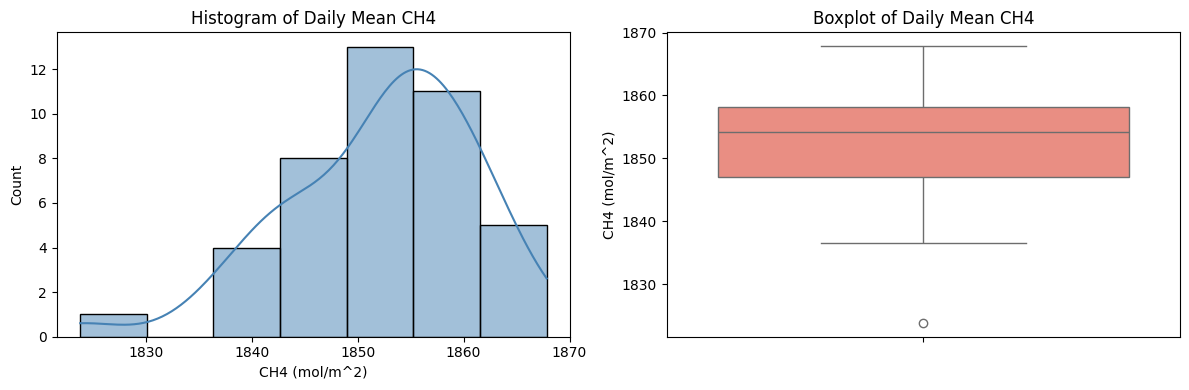

Skewness: -0.8824905833261837
Kurtosis: 1.0851838022845706


In [ ]:
# Distribution plots (histogram & boxplot)
try:
    df
except NameError:
    raise RuntimeError("Run the DataFrame cell first.")

import matplotlib.pyplot as plt
import seaborn as sns

# Install seaborn if missing
try:
    sns.set_theme
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'seaborn'])
    import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(df['mean_ch4'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Histogram of Daily Mean CH4')
axes[0].set_xlabel('CH4 (mol/m^2)')

sns.boxplot(y=df['mean_ch4'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Daily Mean CH4')
axes[1].set_ylabel('CH4 (mol/m^2)')

plt.tight_layout()
plt.show()

print('Skewness:', df['mean_ch4'].skew())
print('Kurtosis:', df['mean_ch4'].kurt())

Anomalies detected:
               mean_ch4    zscore
date                             
2019-06-04  1823.831191 -3.219984


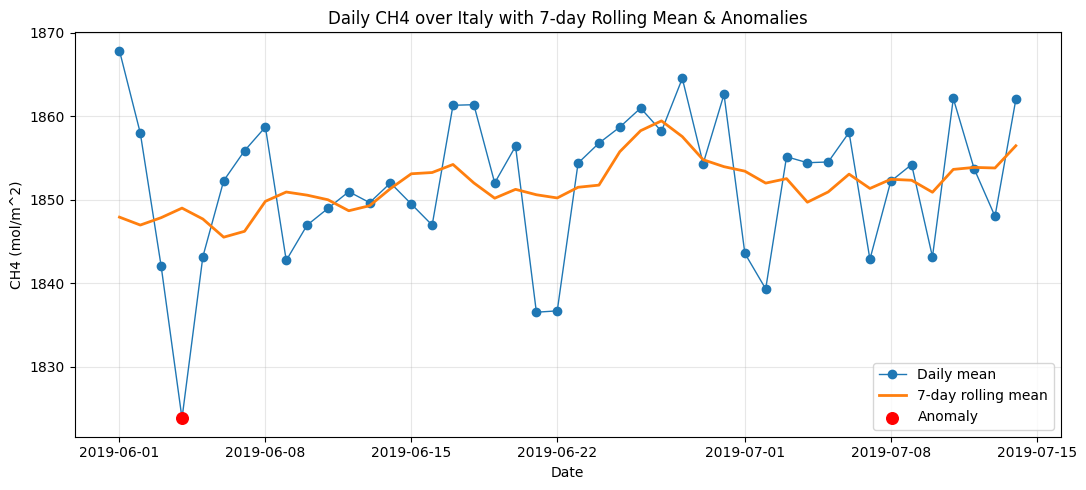

Total anomalies: 1 (|z|>2). Consider verifying data quality or regional events.


In [ ]:
# Rolling 7-day mean and anomaly detection
try:
    df
except NameError:
    raise RuntimeError("Run the DataFrame cell first.")

import matplotlib.pyplot as plt

# Ensure daily frequency (reindex if gaps)
df_daily = df.set_index('date').asfreq('D')
# Forward/back fill small gaps (optional, limit=1 day)
df_daily['mean_ch4'] = df_daily['mean_ch4'].interpolate(limit=1)

# Rolling window (centered)
df_daily['roll7'] = df_daily['mean_ch4'].rolling(window=7, center=True, min_periods=3).mean()

# Z-score relative to full period
global_mean = df_daily['mean_ch4'].mean()
global_std = df_daily['mean_ch4'].std()
df_daily['zscore'] = (df_daily['mean_ch4'] - global_mean) / global_std

# Flag anomalies (|z| > 2)
df_daily['anomaly'] = df_daily['zscore'].abs() > 2

print("Anomalies detected:")
print(df_daily[df_daily['anomaly']][['mean_ch4','zscore']])

plt.figure(figsize=(11,5))
plt.plot(df_daily.index, df_daily['mean_ch4'], label='Daily mean', marker='o', linewidth=1)
plt.plot(df_daily.index, df_daily['roll7'], label='7-day rolling mean', linewidth=2)

# Plot anomalies
anoms = df_daily[df_daily['anomaly']]
plt.scatter(anoms.index, anoms['mean_ch4'], color='red', s=70, zorder=5, label='Anomaly')

plt.title(f'Daily CH4 over {COUNTRY_NAME} with 7-day Rolling Mean & Anomalies')
plt.xlabel('Date')
plt.ylabel('CH4 (mol/m²)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Basic interpretation hint
if not anoms.empty:
    print(f"Total anomalies: {len(anoms)} (|z|>2). Consider verifying data quality or regional events.")
else:
    print("No anomalies beyond |z|>2 threshold.")

In [ ]:
# Interactive map overlay of CH4 over the region

# User-adjustable visualization parameters -------------------------------
composite_method = 'mean'    # 'mean' | 'median' | 'first'
# ------------------------------------------------------------------------

# Use the collection and geometry from configuration
filtered = collection

col_size = filtered.size().getInfo()
print(f"Collection size for {START_DATE} → {END_DATE}: {col_size}")

if col_size == 0:
    print(f"⚠ No images found in date range. Try adjusting START_DATE and END_DATE in the configuration cell.")
else:
    if composite_method == 'mean':
        image = filtered.mean()
    elif composite_method == 'median':
        image = filtered.median()
    elif composite_method == 'first':
        image = ee.Image(filtered.first())
    else:
        raise ValueError("Unsupported composite_method; choose 'mean','median','first'.")

    # Verify image has the band before continuing
    band_names = image.bandNames().getInfo()
    if BAND_NAME not in band_names:
        print("⚠ Composite produced no bands. Aborting visualization.")
    else:
        image = image.select(BAND_NAME).clip(region_geom)

        # Quantile stretch with fallback
        try:
            q = image.reduceRegion(
                reducer=ee.Reducer.percentile([5,95]),
                geometry=region_geom,
                scale=10000,
                bestEffort=True,
                maxPixels=1e9
            ).getInfo()
            p5  = q.get(f'{BAND_NAME}_p5') if q else None
            p95 = q.get(f'{BAND_NAME}_p95') if q else None
        except Exception as e:
            print('Quantile reduction failed, using defaults (1800-1900).', e)
            p5, p95 = None, None

        vmin = 1800 if (p5 is None) else p5
        vmax = 1900 if (p95 is None) else p95
        if vmin == vmax:
            vmax = vmin + 1  # avoid zero range

        vis_params = {
            'min': vmin,
            'max': vmax,
            'palette': ['0d0887','5c01a6','9c179e','cc4778','ed7953','fb9f3a','fdca26','f0f921']
        }
        print(f'Visualization stretch: {vis_params["min"]:.1f} to {vis_params["max"]:.1f}')

        # Get region center for map
        centroid = region_geom.centroid().coordinates().getInfo()
        center_lon, center_lat = centroid[0], centroid[1]

        # Try geemap; fallback to folium
        _use_geemap = True
        try:
            import geemap.foliumap as geemap
        except Exception:
            _use_geemap = False

        if _use_geemap:
            m = geemap.Map(center=[center_lat, center_lon], zoom=5)
            m.addLayer(image, vis_params, f'CH4 {composite_method} {START_DATE} to {END_DATE}')
            m.addLayerControl()
            try:
                m.add_colorbar(vis_params=vis_params, label='CH4 (mol/m²)')
            except Exception:
                pass
            display(m)
        else:
            import folium
            m = folium.Map(location=[center_lat, center_lon], zoom_start=5, tiles='cartodbpositron')
            def add_ee_layer(folium_map, ee_image, vis, name):
                map_info = ee_image.getMapId(vis)
                tile_url = map_info['tile_fetcher'].url_format
                folium.raster_layers.TileLayer(
                    tiles=tile_url,
                    attr='Google Earth Engine',
                    name=name,
                    overlay=True,
                    control=True
                ).add_to(folium_map)
                return tile_url
            tile_url = add_ee_layer(m, image, vis_params, f'CH4 {composite_method}')
            folium.LayerControl().add_to(m)
            display(m)
            print('\nTile URL template (use in Leaflet frontend):')
            print(tile_url)

        # Tile template for external integration
        try:
            map_info = image.getMapId(vis_params)
            tile_template = map_info['tile_fetcher'].url_format
            print('\nReusable tile URL template:')
            print(tile_template)
        except Exception as e:
            print('Could not generate tile URL template:', e)

        # Static thumbnail
        try:
            thumb_params = {
                'region': region_geom,
                'min': vis_params['min'],
                'max': vis_params['max'],
                'dimensions': 512,
                'palette': vis_params['palette']
            }
            thumb_url = image.getThumbURL(thumb_params)
            print('\nStatic thumbnail URL:', thumb_url)
        except Exception as e:
            print('Thumbnail generation failed:', e)


Filtered collection size for 2019-01-01 -> 2019-02-01: 438
Visualization stretch: 1833.750188343919 to 1871.3286604755642
Visualization stretch: 1833.750188343919 to 1871.3286604755642


Tile URL template (use in Leaflet frontend):
https://earthengine.googleapis.com/v1/projects/quick-composite-408320/maps/a45151764546ea54166d0a4ba05333eb-c5346db08c0eecadae6e29328657cfdd/tiles/{z}/{x}/{y}

Reusable tile URL template:
https://earthengine.googleapis.com/v1/projects/quick-composite-408320/maps/a45151764546ea54166d0a4ba05333eb-dc25d991f9f973fdfc747f5bb0915028/tiles/{z}/{x}/{y}

Reusable tile URL template:
https://earthengine.googleapis.com/v1/projects/quick-composite-408320/maps/a45151764546ea54166d0a4ba05333eb-dc25d991f9f973fdfc747f5bb0915028/tiles/{z}/{x}/{y}

Static thumbnail URL: https://earthengine.googleapis.com/v1/projects/quick-composite-408320/thumbnails/859c203b641562fca3c70220712bd9da-f9825251c1f91a13579529a5cbfe84c9:getPixels

Static thumbnail URL: https://earthengine.googleapis.com/v1/projects/quick-composite-408320/thumbnails/859c203b641562fca3c70220712bd9da-f9825251c1f91a13579529a5cbfe84c9:getPixels


# Data Report: Sentinel-5P Methane (CH4) Analysis

## Configuration
This notebook analyzes CH4 data based on the configuration variables set at the top:
- **Region**: Configurable via `COUNTRY_NAME` variable
- **Date Range**: Configurable via `START_DATE` and `END_DATE` variables
- **Band**: Configurable via `BAND_NAME` variable

## Data Structure

Two conceptual layers of data:
1. **Raw imagery**: Individual overpass images (multiple per day) with per-pixel CH4 values
2. **Aggregated dataset**: Daily mean CH4 over the selected region (after filtering images that contain valid pixels)

You can recompute counts dynamically:
```python
raw_size = collection.size().getInfo()
valid_size = valid_collection.size().getInfo()
if 'df' in globals() and not df.empty:
    unique_days = df['date'].nunique()
    print(f"Raw images: {raw_size}, Valid images: {valid_size}, Unique days: {unique_days}")
```

## Features / Dimensions
Final analytical table (`df`, created if there's enough data):
- `date` (datetime64[ns]): Calendar date of observation
- `mean_ch4` (float): Mean methane column (mol/m²) over the region for that date

## How to Use This Notebook

1. **Configure parameters** in the second cell (region, dates, etc.)
2. **Run authentication** cell to initialize Earth Engine
3. **Load and filter data** to get valid observations
4. **Analyze** using the pandas DataFrame (if you have multiple days of data)
5. **Visualize** using the interactive map

## Notes
- For small date ranges (1-2 days), you may only get a few data points
- Statistical analysis cells require multiple days of data to be meaningful
- The region can be any country available in FAO/GAUL/2015/level0 dataset
